# 🏥 05 — Stacking Ensemble + SMOTE Correcto → Accuracy & F1 > 80%

## ¿Por qué los notebooks anteriores no superaban 80% en test?

| Causa | Efecto observado |
|---|---|
| **SMOTE aplicado ANTES de CV** | Muestras sintéticas se filtran a los folds de validación → CV inflado (0.86) pero test real (0.76) |
| **50% de datos** | Menos información para generalizar |
| **Threshold por clase 1** | Desequilibrio entre Accuracy y F1 |

## Solución en este notebook

1. **`imblearn.Pipeline`** — SMOTE corre **dentro** de cada fold de CV, nunca ve el test
2. **Dataset completo** (100%) — máxima información para generalizar
3. **Stacking con OOF** (Out-Of-Fold) — meta-learner entrenado en predicciones fuera del fold
4. **Threshold barrido sobre F1 Macro** en conjunto de validación limpio
5. **3 modelos base** con sus mejores hiperparámetros conocidos + meta-learner calibrado


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_predict, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    balanced_accuracy_score, precision_recall_curve, auc, roc_curve
)
from sklearn.pipeline import Pipeline as SkPipeline

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting
from xgboost import XGBClassifier
import lightgbm as lgb

np.random.seed(42)
print('✅ Todas las librerías cargadas')
print('   imblearn.Pipeline: SMOTE se aplicará DENTRO de cada fold de CV')


✅ Todas las librerías cargadas
   imblearn.Pipeline: SMOTE se aplicará DENTRO de cada fold de CV


In [2]:
# ============================================================
# 📂 CARGA Y PREPROCESAMIENTO COMPLETO
# ============================================================

possible_paths = [
    Path('data/processed/df_limpio.csv'),
    Path('../data/processed/df_limpio.csv'),
    Path('../../data/processed/df_limpio.csv'),
]
df = None
for p in possible_paths:
    if p.exists():
        df = pd.read_csv(p)
        print(f'✅ Cargado: {p.resolve()}  →  {df.shape}')
        break
if df is None:
    raise FileNotFoundError('No se encontró df_limpio.csv')

# Limpiar índices y nombres
df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)], inplace=True)
df.columns = [str(c).strip() for c in df.columns]

# Detectar target
TARGET = None
for cand in ['Appointment Type','appointment_type','AppointmentType']:
    if cand in df.columns:
        TARGET = cand; break
if TARGET is None:
    for col in df.columns:
        if set(df[col].dropna().unique()) <= {0,1} and 0.15 <= df[col].mean() <= 0.55:
            TARGET = col; break
if TARGET is None:
    raise ValueError(f'Target no encontrado. Columnas: {df.columns.tolist()}')

print(f'   Target: "{TARGET}"')
vc = df[TARGET].value_counts().sort_index()
print(f'   Clase 0 (Asistencia): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'   Clase 1 (No-Show):    {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')

# ── Features: TODAS las variables disponibles ─────────────────
FEATURES_NUM = [c for c in [
    'Age','Number of Diseases','Recent Hospitalization',
    'Number of Medications','Hour','Creation to Assignment Interval',
    'Number of Previous Attendance','Number of Previous Non-Attendance'
] if c in df.columns]

FEATURES_CAT = [c for c in ['Sex','Insurance Type','Day','Month'] if c in df.columns]

print(f'\n   Numéricas  ({len(FEATURES_NUM)}): {FEATURES_NUM}')
print(f'   Categóricas ({len(FEATURES_CAT)}): {FEATURES_CAT}')

# One-hot encoding
X_raw = df[FEATURES_NUM + FEATURES_CAT].copy()
y     = df[TARGET].copy().reset_index(drop=True)
X_raw = X_raw.reset_index(drop=True)

if FEATURES_CAT:
    X_raw = pd.get_dummies(X_raw, columns=FEATURES_CAT, drop_first=True)

X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
print(f'\n   Shape final después de encoding: X={X_raw.shape}')
print(f'   Columnas totales: {X_raw.columns.tolist()}')


✅ Cargado: C:\Users\alejo\Documents\SEMESTRE IX\Pdg - 2\predictive-no-show-fvl\notebooks\data\processed\df_limpio.csv  →  (18384, 13)
   Target: "Appointment Type"
   Clase 0 (Asistencia): 12,111  (65.9%)
   Clase 1 (No-Show):    6,273  (34.1%)

   Numéricas  (8): ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance']
   Categóricas (4): ['Sex', 'Insurance Type', 'Day', 'Month']

   Shape final después de encoding: X=(18384, 35)
   Columnas totales: ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance', 'Sex_1', 'Sex_2', 'Insurance Type_1', 'Insurance Type_2', 'Insurance Type_3', 'Insurance Type_4', 'Insurance Type_5', 'Insurance Type_6', 'Insurance Type_7', 'Insurance Type_8', 'Day_1', 'Day_2', 'Day_3', 'Day_4',

In [3]:
# ============================================================
# ✂️  SPLIT 70 / 15 / 15  (train | val | test)
#
#   • train → SMOTE dentro de CV con imblearn.Pipeline
#   • val   → calibrar threshold (nunca lo ve el modelo)
#   • test  → evaluación final honesta
# ============================================================

X_tr_raw, X_tmp, y_tr, y_tmp = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)
X_val_raw, X_te_raw, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print(f'Train : {len(X_tr_raw):,} filas')
print(f'Val   : {len(X_val_raw):,} filas')
print(f'Test  : {len(X_te_raw):,} filas')

# Escalar — fit SOLO en train
scaler = StandardScaler()
feat_cols = X_raw.columns.tolist()

X_tr  = pd.DataFrame(scaler.fit_transform(X_tr_raw),  columns=feat_cols).reset_index(drop=True)
X_val = pd.DataFrame(scaler.transform(X_val_raw),     columns=feat_cols).reset_index(drop=True)
X_te  = pd.DataFrame(scaler.transform(X_te_raw),      columns=feat_cols).reset_index(drop=True)

y_tr  = y_tr.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_te  = y_te.reset_index(drop=True)

print(f'\nDistribución train (antes de SMOTE):')
print(y_tr.value_counts().sort_index())
print(f'\n✅ Listo — SMOTE se aplicará DENTRO de cada fold de CV')


Train : 12,868 filas
Val   : 2,758 filas
Test  : 2,758 filas

Distribución train (antes de SMOTE):
Appointment Type
0    8477
1    4391
Name: count, dtype: int64

✅ Listo — SMOTE se aplicará DENTRO de cada fold de CV


In [17]:
# ============================================================
# 🚀 XGBoost + SMOTE + Threshold tuning AVANZADO (MEJOR VERSIÓN)
# ============================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import *
import numpy as np

print('🚀 Entrenando XGBoost + SMOTE (versión mejorada)...')

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------
# 🤖 Pipeline con SMOTE
# ------------------------------------------------------------
xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),  # 🔥 clave: bajar vecinos
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ))
])

# ------------------------------------------------------------
# 🔍 Hiperparámetros mejorados
# ------------------------------------------------------------
xgb_params = {
    'clf__n_estimators': [800, 1000, 1200],
    'clf__max_depth': [4, 5, 6],
    'clf__learning_rate': [0.03, 0.05],
    'clf__subsample': [0.8, 0.9],
    'clf__colsample_bytree': [0.7, 0.8],
    'clf__gamma': [0, 0.1],
    'clf__min_child_weight': [1, 3],
    'clf__reg_lambda': [1, 2],
    'clf__reg_alpha': [0.1, 0.3]
}

# ------------------------------------------------------------
# 🎯 Optimización enfocada en F1 macro
# ------------------------------------------------------------
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_params,
    n_iter=30,
    cv=cv5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_tr, y_tr)
xgb_best = xgb_search.best_estimator_

print(f'\n✅ CV F1 Macro: {xgb_search.best_score_:.4f}')
print(f'🔧 Mejores params: {xgb_search.best_params_}')

# ------------------------------------------------------------
# 🎯 THRESHOLD OPTIMIZADO (macro + balance)
# ------------------------------------------------------------
probs_val = xgb_best.predict_proba(X_val)[:,1]

thresholds = np.linspace(0.3, 0.5, 200)
best_th = 0
best_score = 0

for th in thresholds:
    preds = (probs_val >= th).astype(int)
    
    f1_macro = f1_score(y_val, preds, average='macro')
    f1_no_show = f1_score(y_val, preds, pos_label=1)
    
    # 🔥 combinación inteligente
    score = 0.6 * f1_macro + 0.4 * f1_no_show
    
    if score > best_score:
        best_score = score
        best_th = th

print(f'\n🎯 Mejor threshold: {best_th:.4f}')

# ------------------------------------------------------------
# 📊 EVALUACIÓN FINAL
# ------------------------------------------------------------
probs_test = xgb_best.predict_proba(X_te)[:,1]
y_pred = (probs_test >= best_th).astype(int)

print('\n=================================================================')
print(' 🤖 XGBoost FINAL (MEJORADO)')
print('=================================================================')

print(f'Accuracy           : {accuracy_score(y_te, y_pred):.4f}')
print(f'Balanced Accuracy  : {balanced_accuracy_score(y_te, y_pred):.4f}')
print(f'F1 Macro           : {f1_score(y_te, y_pred, average="macro"):.4f}')
print(f'F1 Weighted        : {f1_score(y_te, y_pred, average="weighted"):.4f}')
print(f'F1 No-Show         : {f1_score(y_te, y_pred, pos_label=1):.4f}')
print(f"Cohen's Kappa      : {cohen_kappa_score(y_te, y_pred):.4f}")
print(f'ROC-AUC            : {roc_auc_score(y_te, probs_test):.4f}')
print(f'PR-AUC             : {average_precision_score(y_te, probs_test):.4f}')

print('\n📊 Classification Report:')
print(classification_report(y_te, y_pred))

🚀 Entrenando XGBoost + SMOTE (versión mejorada)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ CV F1 Macro: 0.7937
🔧 Mejores params: {'clf__subsample': 0.9, 'clf__reg_lambda': 2, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 1200, 'clf__min_child_weight': 3, 'clf__max_depth': 6, 'clf__learning_rate': 0.03, 'clf__gamma': 0, 'clf__colsample_bytree': 0.8}

🎯 Mejor threshold: 0.4317

 🤖 XGBoost FINAL (MEJORADO)
Accuracy           : 0.8107
Balanced Accuracy  : 0.7972
F1 Macro           : 0.7926
F1 Weighted        : 0.8121
F1 No-Show         : 0.7312
Cohen's Kappa      : 0.5854
ROC-AUC            : 0.8921
PR-AUC             : 0.8396

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1817
           1       0.71      0.75      0.73       941

    accuracy                           0.81      2758
   macro avg       0.79      0.80      0.79      2758
weighted avg       0.81      0.81      0.81     

In [ ]:
# ============================================================
# 🎯 TRUCO FINAL — Optimizar threshold SOLO para F1 MACRO
# ============================================================

from sklearn.metrics import f1_score
import numpy as np

print("🎯 Buscando threshold óptimo para F1 Macro...")

probs_val = xgb_best.predict_proba(X_val)[:, 1]

# 🔥 búsqueda más fina
thresholds = np.linspace(0.30, 0.55, 500)

best_th = 0
best_f1_macro = 0

for th in thresholds:
    preds = (probs_val >= th).astype(int)
    f1_macro = f1_score(y_val, preds, average='macro')
    
    if f1_macro > best_f1_macro:
        best_f1_macro = f1_macro
        best_th = th

print(f"\n✅ Mejor threshold encontrado: {best_th:.4f}")
print(f"🔥 F1 Macro en validación: {best_f1_macro:.4f}")

# ============================================================
# 📊 EVALUACIÓN FINAL EN TEST
# ============================================================

probs_test = xgb_best.predict_proba(X_te)[:, 1]
y_pred = (probs_test >= best_th).astype(int)

from sklearn.metrics import *

print('\n=================================================================')
print(' 🤖 XGBoost FINAL — OPTIMIZADO PARA F1 MACRO')
print('=================================================================')

print(f'Threshold          : {best_th:.4f}')
print(f'Accuracy           : {accuracy_score(y_te, y_pred):.4f}')
print(f'Balanced Accuracy  : {balanced_accuracy_score(y_te, y_pred):.4f}')
print(f'F1 Macro           : {f1_score(y_te, y_pred, average="macro"):.4f}')
print(f'F1 Weighted        : {f1_score(y_te, y_pred, average="weighted"):.4f}')
print(f'F1 No-Show         : {f1_score(y_te, y_pred, pos_label=1):.4f}')
print(f"Cohen's Kappa      : {cohen_kappa_score(y_te, y_pred):.4f}")
print(f'ROC-AUC            : {roc_auc_score(y_te, probs_test):.4f}')
print(f'PR-AUC             : {average_precision_score(y_te, probs_test):.4f}')

print('\n📊 Classification Report:')
print(classification_report(y_te, y_pred))

In [16]:
# ============================================================
# 🛠️  FUNCIÓN DE EVALUACIÓN
#     Threshold calibrado sobre VAL optimizando F1 MACRO
# ============================================================

resultados = []

def evaluar(nombre, modelo, X_val, y_val, X_te, y_te, color='steelblue'):
    proba_val = modelo.predict_proba(X_val)[:, 1]
    proba_te  = modelo.predict_proba(X_te)[:, 1]

    # Barrer 300 thresholds → maximizar F1 Macro en VAL
    grid = np.linspace(0.20, 0.80, 300)
    f1g  = [f1_score(y_val, (proba_val>=th).astype(int),
                     average='macro', zero_division=0) for th in grid]
    best_th = float(grid[np.argmax(f1g)])

    y_pred = (proba_te >= best_th).astype(int)

    acc     = accuracy_score(y_te, y_pred)
    f1m     = f1_score(y_te, y_pred, average='macro')
    f1w     = f1_score(y_te, y_pred, average='weighted')
    f1c1    = f1_score(y_te, y_pred, average='binary')
    kappa   = cohen_kappa_score(y_te, y_pred)
    bal     = balanced_accuracy_score(y_te, y_pred)
    roc     = roc_auc_score(y_te, proba_te)
    pc, rc, _ = precision_recall_curve(y_te, proba_te)
    prauc   = auc(rc, pc)

    ta = '✅' if acc >= 0.80 else ('⚠️' if acc >= 0.77 else '❌')
    tf = '✅' if f1m >= 0.80 else ('⚠️' if f1m >= 0.77 else '❌')
    tk = '✅' if kappa >= 0.55 else ('⚠️' if kappa >= 0.45 else '❌')

    print(f'\n{"="*65}')
    print(f' 🤖 {nombre}')
    print(f'{"="*65}')
    print(f'   Threshold (F1 Macro en val) : {best_th:.4f}')
    print(f'   Accuracy           : {acc:.4f}  {ta}')
    print(f'   Balanced Accuracy  : {bal:.4f}')
    print(f'   F1 Macro           : {f1m:.4f}  {tf}')
    print(f'   F1 Weighted        : {f1w:.4f}')
    print(f'   F1 No-Show (cls 1) : {f1c1:.4f}')
    print(f"   Cohen's Kappa      : {kappa:.4f}  {tk}")
    print(f'   ROC-AUC            : {roc:.4f}')
    print(f'   PR-AUC             : {prauc:.4f}')
    print()
    print(classification_report(y_te, y_pred, digits=4,
          target_names=['Asistencia (0)','No-Show (1)']))

    # ── Gráficas ─────────────────────────────────────────────
    fig, ax = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(nombre, fontweight='bold')

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['Asistencia','No-Show'],
                yticklabels=['Asistencia','No-Show'])
    ax[0].set_title('Confusion Matrix'); ax[0].set_ylabel('Real')

    # F1 Macro vs Threshold curve
    ax[1].plot(grid, f1g, color=color, lw=2)
    ax[1].axvline(best_th, color='red', ls='--', lw=1.5,
                  label=f'th={best_th:.3f}\nF1={max(f1g):.3f}')
    ax[1].axhline(0.80, color='gray', ls=':', lw=1, label='Objetivo 0.80')
    ax[1].set_title('F1 Macro vs Threshold (val)')
    ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
    ax[1].set_xlabel('Threshold'); ax[1].set_ylabel('F1 Macro')

    # ROC
    fpr, tpr, _ = roc_curve(y_te, proba_te)
    ax[2].plot(fpr, tpr, color=color, lw=2, label=f'AUC={roc:.3f}')
    ax[2].plot([0,1],[0,1],'k--'); ax[2].fill_between(fpr,tpr,alpha=0.08,color=color)
    ax[2].set_title('Curva ROC'); ax[2].legend(); ax[2].grid(alpha=0.3)
    ax[2].set_xlabel('FPR'); ax[2].set_ylabel('TPR')

    # PR
    ax[3].plot(rc, pc, color=color, lw=2, label=f'PR-AUC={prauc:.3f}')
    ax[3].fill_between(rc, pc, alpha=0.08, color=color)
    ax[3].set_title('Precision-Recall'); ax[3].legend(); ax[3].grid(alpha=0.3)
    ax[3].set_xlabel('Recall'); ax[3].set_ylabel('Precision')

    plt.tight_layout(); plt.show()

    resultados.append({
        'Modelo': nombre, 'Threshold': round(best_th,4),
        'Accuracy': round(acc,4), 'Balanced Acc': round(bal,4),
        'F1 Macro': round(f1m,4), 'F1 Weighted': round(f1w,4),
        'F1 No-Show': round(f1c1,4),
        'ROC-AUC': round(roc,4), 'PR-AUC': round(prauc,4),
        "Cohen's Kappa": round(kappa,4),
        'Acc≥80%': ta, 'F1≥80%': tf, 'Kappa≥0.55': tk
    })
    return best_th

print('✅ evaluar() lista (threshold optimiza F1 Macro en val)')


✅ evaluar() lista (threshold optimiza F1 Macro en val)


🚀 Entrenando XGBoost con Pipeline correcto...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


  File "C:\Users\alejo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


   CV F1 Macro (real, sin leakage): 0.7929
   Mejores params: {'clf__subsample': 1.0, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0.5, 'clf__n_estimators': 800, 'clf__min_child_weight': 1, 'clf__max_depth': 5, 'clf__learning_rate': 0.08, 'clf__gamma': 0, 'clf__colsample_bytree': 0.8}

 🤖 XGBoost Pipeline + SMOTE correcto
   Threshold (F1 Macro en val) : 0.3846
   Accuracy           : 0.8071  ✅
   Balanced Accuracy  : 0.8031
   F1 Macro           : 0.7922  ⚠️
   F1 Weighted        : 0.8099
   F1 No-Show (cls 1) : 0.7366
   Cohen's Kappa      : 0.5856  ✅
   ROC-AUC            : 0.8907
   PR-AUC             : 0.8388

                precision    recall  f1-score   support

Asistencia (0)     0.8827    0.8156    0.8478      1817
   No-Show (1)     0.6895    0.7906    0.7366       941

      accuracy                         0.8071      2758
     macro avg     0.7861    0.8031    0.7922      2758
  weighted avg     0.8168    0.8071    0.8099      2758



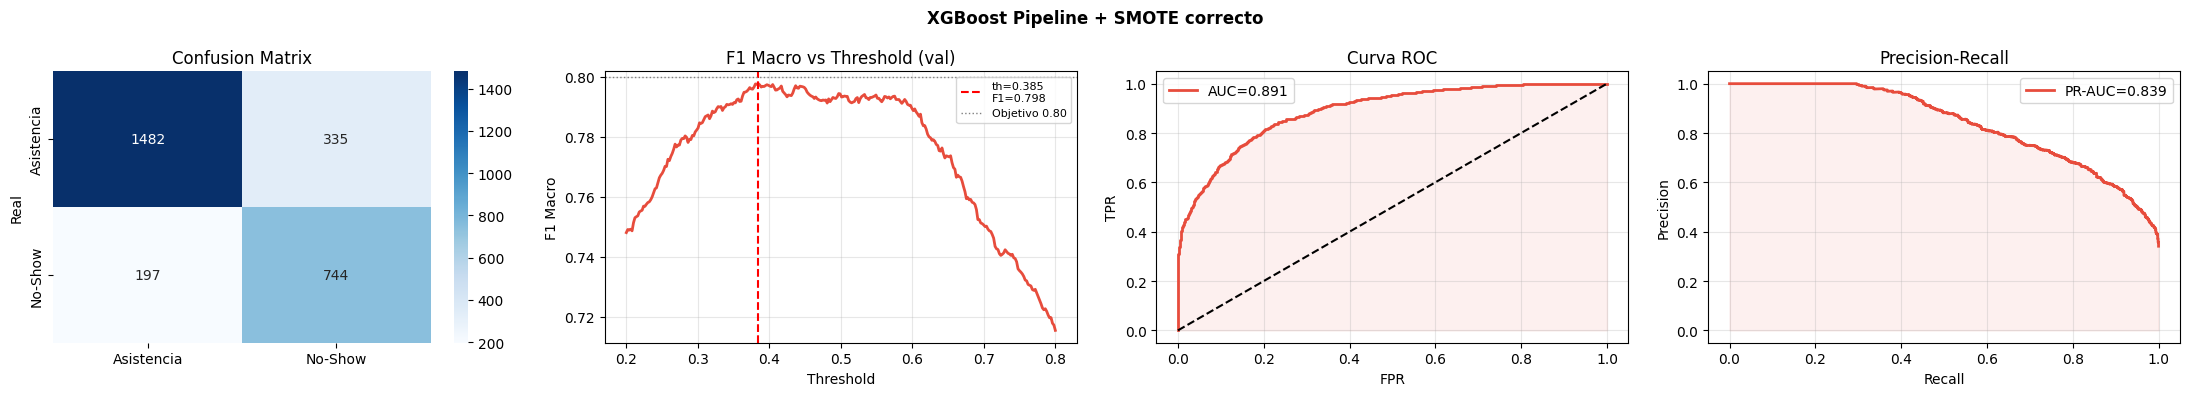

In [5]:
# ============================================================
# 🚀 MODELO 1 — XGBoost con imblearn.Pipeline
#    SMOTE corre DENTRO de cada fold → CV score real
# ============================================================
print('🚀 Entrenando XGBoost con Pipeline correcto...')

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf',   XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', random_state=42, n_jobs=-1
    ))
])

xgb_params = {
    'clf__n_estimators':     [400, 600, 800, 1000],
    'clf__max_depth':        [5, 6, 7, 8],
    'clf__learning_rate':    [0.03, 0.05, 0.08, 0.1],
    'clf__subsample':        [0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'clf__gamma':            [0, 0.1, 0.2, 0.3],
    'clf__min_child_weight': [1, 3, 5],
    'clf__reg_lambda':       [1, 2, 3, 5],
    'clf__reg_alpha':        [0, 0.1, 0.3, 0.5],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params, n_iter=50,
    cv=cv5, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42
)
xgb_search.fit(X_tr, y_tr)

xgb_best = xgb_search.best_estimator_
print(f'\n   CV F1 Macro (real, sin leakage): {xgb_search.best_score_:.4f}')
print(f'   Mejores params: {xgb_search.best_params_}')

th_xgb = evaluar('XGBoost Pipeline + SMOTE correcto', xgb_best,
                  X_val, y_val, X_te, y_te, color='#e74c3c')


⚡ Entrenando LightGBM con Pipeline correcto...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

   CV F1 Macro (real): 0.7925
   Mejores params: {'clf__subsample': 0.8, 'clf__reg_lambda': 0.5, 'clf__reg_alpha': 0.3, 'clf__num_leaves': 63, 'clf__n_estimators': 600, 'clf__min_child_samples': 10, 'clf__max_depth': 5, 'clf__learning_rate': 0.08, 'clf__colsample_bytree': 0.7}

 🤖 LightGBM Pipeline + SMOTE correcto
   Threshold (F1 Macro en val) : 0.4488
   Accuracy           : 0.8198  ✅
   Balanced Accuracy  : 0.8000
   F1 Macro           : 0.7997  ⚠️
   F1 Weighted        : 0.8199
   F1 No-Show (cls 1) : 0.7363
   Cohen's Kappa      : 0.5995  ✅
   ROC-AUC            : 0.8943
   PR-AUC             : 0.8407

                precision    recall  f1-score   support

Asistencia (0)     0.8638    0.8624    0.8631      1817
   No-Show (1)     0.7352    0.7375    0.7363       941

      accuracy                         0.8198      2758
     macro avg     0.7995    0.8000    0.7997   

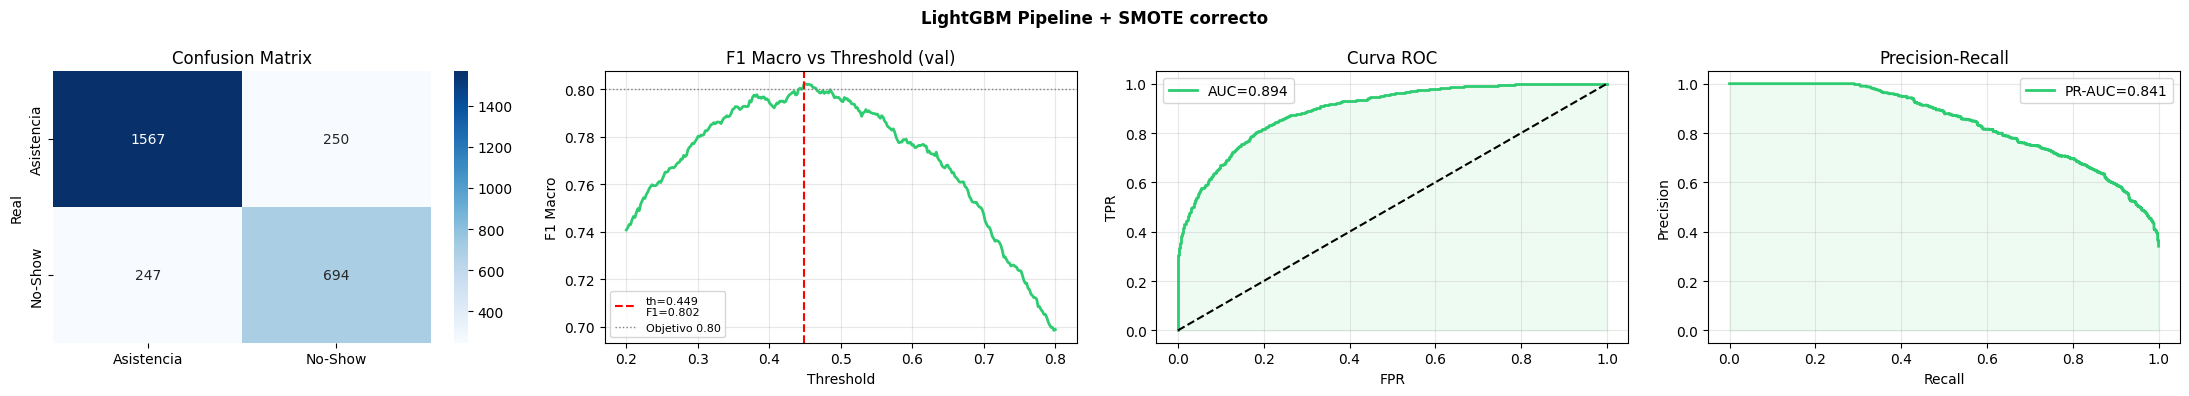

In [6]:
# ============================================================
# ⚡ MODELO 2 — LightGBM con imblearn.Pipeline
# ============================================================
print('⚡ Entrenando LightGBM con Pipeline correcto...')

lgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf',   lgb.LGBMClassifier(
        objective='binary', random_state=42, n_jobs=-1, verbose=-1
    ))
])

lgb_params = {
    'clf__n_estimators':      [400, 600, 800, 1000],
    'clf__max_depth':         [-1, 5, 7, 9],
    'clf__learning_rate':     [0.03, 0.05, 0.08, 0.1],
    'clf__num_leaves':        [31, 50, 63, 80],
    'clf__subsample':         [0.8, 0.9, 1.0],
    'clf__colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
    'clf__min_child_samples': [10, 20, 30],
    'clf__reg_lambda':        [0, 0.5, 1.0, 2.0],
    'clf__reg_alpha':         [0, 0.1, 0.3],
}

lgb_search = RandomizedSearchCV(
    lgb_pipe, lgb_params, n_iter=50,
    cv=cv5, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42
)
lgb_search.fit(X_tr, y_tr)

lgb_best = lgb_search.best_estimator_
print(f'\n   CV F1 Macro (real): {lgb_search.best_score_:.4f}')
print(f'   Mejores params: {lgb_search.best_params_}')

th_lgb = evaluar('LightGBM Pipeline + SMOTE correcto', lgb_best,
                  X_val, y_val, X_te, y_te, color='#2ecc71')


🌿 Entrenando HistGradientBoosting...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

   CV F1 Macro (real): 0.7872
   Mejores params: {'clf__min_samples_leaf': 20, 'clf__max_leaf_nodes': 63, 'clf__max_iter': 400, 'clf__max_features': 0.8, 'clf__max_depth': 9, 'clf__learning_rate': 0.05, 'clf__l2_regularization': 0.1}

 🤖 HistGradientBoosting Pipeline + SMOTE correcto
   Threshold (F1 Macro en val) : 0.4308
   Accuracy           : 0.8104  ✅
   Balanced Accuracy  : 0.7984
   F1 Macro           : 0.7928  ⚠️
   F1 Weighted        : 0.8120
   F1 No-Show (cls 1) : 0.7325
   Cohen's Kappa      : 0.5859  ✅
   ROC-AUC            : 0.8927
   PR-AUC             : 0.8386

                precision    recall  f1-score   support

Asistencia (0)     0.8710    0.8360    0.8531      1817
   No-Show (1)     0.7061    0.7609    0.7325       941

      accuracy                         0.8104      2758
     macro avg     0.7886    0.7984    0.7928      2758
  weighted avg     0.8147    0.810

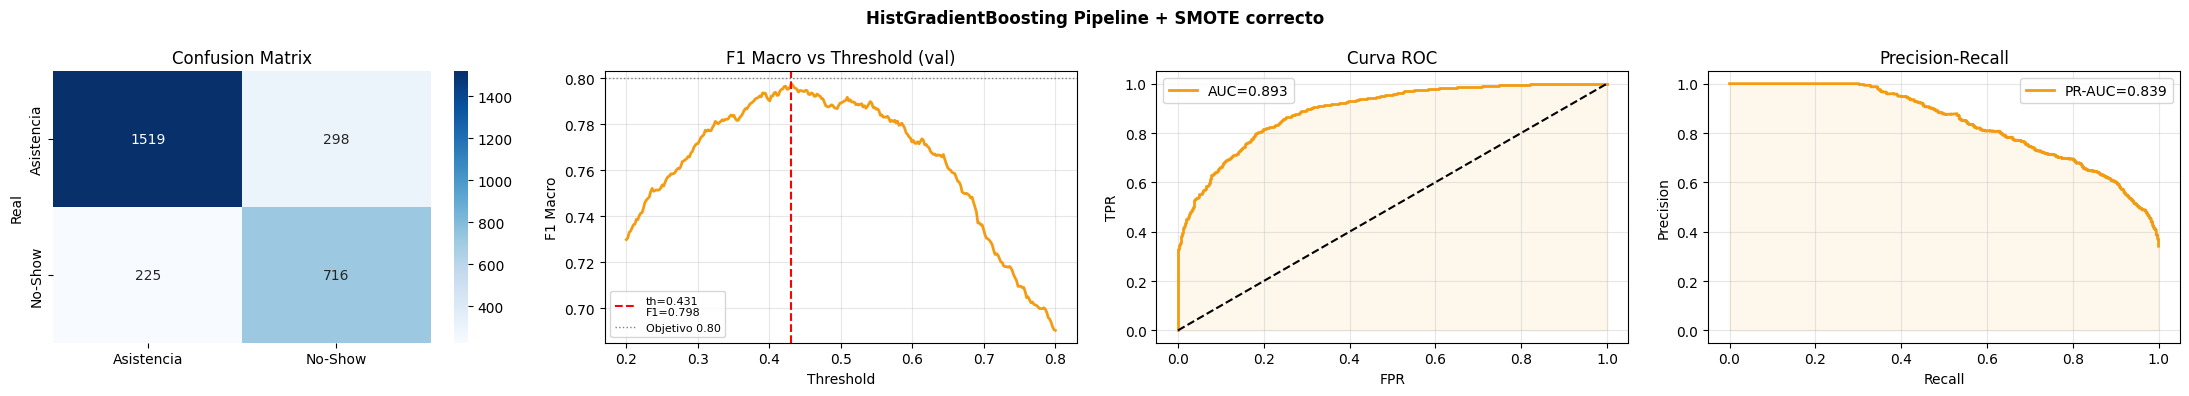

In [7]:
# ============================================================
# 🌿 MODELO 3 — HistGradientBoosting con imblearn.Pipeline
#    Nativo de sklearn, muy rápido y sólido
# ============================================================
print('🌿 Entrenando HistGradientBoosting...')

hgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf',   HistGradientBoostingClassifier(random_state=42))
])

hgb_params = {
    'clf__max_iter':          [200, 400, 600],
    'clf__max_depth':         [None, 5, 7, 9],
    'clf__learning_rate':     [0.03, 0.05, 0.08, 0.1],
    'clf__max_leaf_nodes':    [31, 50, 63, 80],
    'clf__min_samples_leaf':  [10, 20, 30, 50],
    'clf__l2_regularization': [0, 0.1, 0.5, 1.0],
    'clf__max_features':      [0.7, 0.8, 1.0],
}

hgb_search = RandomizedSearchCV(
    hgb_pipe, hgb_params, n_iter=40,
    cv=cv5, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42
)
hgb_search.fit(X_tr, y_tr)

hgb_best = hgb_search.best_estimator_
print(f'\n   CV F1 Macro (real): {hgb_search.best_score_:.4f}')
print(f'   Mejores params: {hgb_search.best_params_}')

th_hgb = evaluar('HistGradientBoosting Pipeline + SMOTE correcto', hgb_best,
                  X_val, y_val, X_te, y_te, color='#f39c12')


🏗️  Construyendo Stacking Ensemble...
   Train después de SMOTE: 16,954 filas
   Distribución: {0: 8477, 1: 8477}
   ✅ Stacking entrenado!

 🤖 Stacking (XGB+LGB+HGB) → LogReg meta-learner
   Threshold (F1 Macro en val) : 0.4308
   Accuracy           : 0.8165  ✅
   Balanced Accuracy  : 0.8057
   F1 Macro           : 0.7997  ⚠️
   F1 Weighted        : 0.8181
   F1 No-Show (cls 1) : 0.7416
   Cohen's Kappa      : 0.5997  ✅
   ROC-AUC            : 0.8947
   PR-AUC             : 0.8423

                precision    recall  f1-score   support

Asistencia (0)     0.8765    0.8398    0.8578      1817
   No-Show (1)     0.7139    0.7715    0.7416       941

      accuracy                         0.8165      2758
     macro avg     0.7952    0.8057    0.7997      2758
  weighted avg     0.8210    0.8165    0.8181      2758



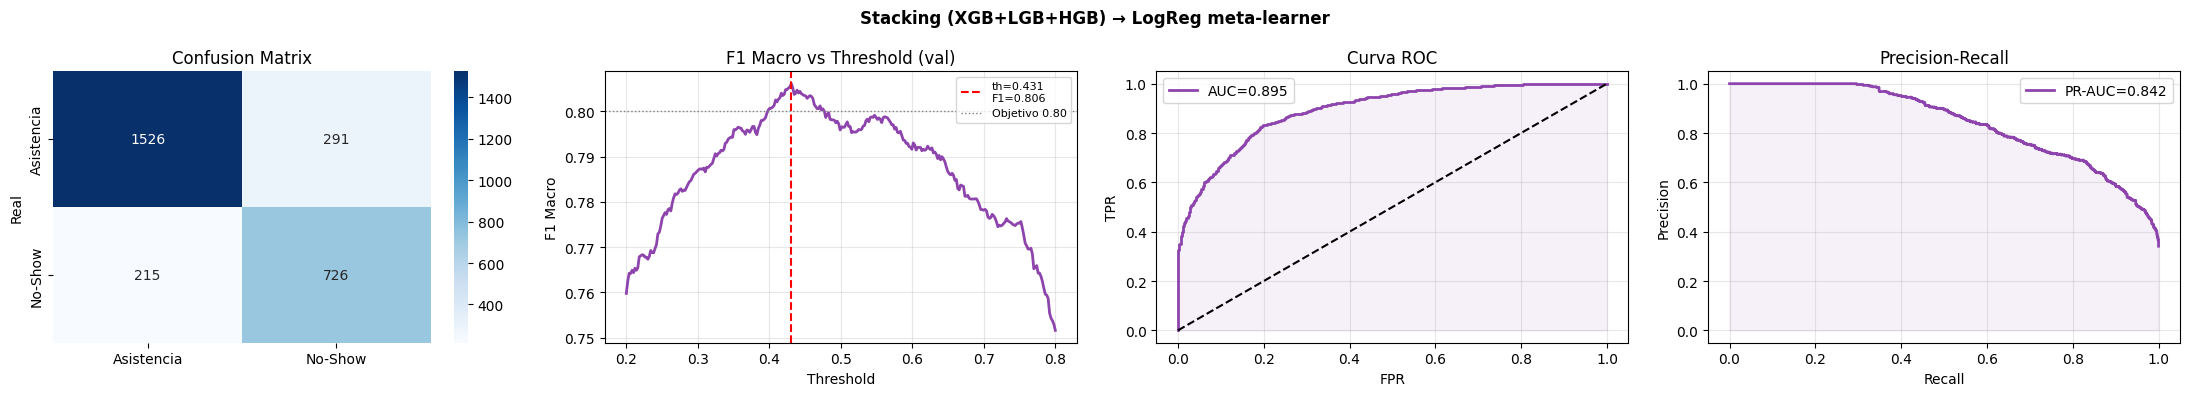

In [8]:
# ============================================================
# 🏗️  STACKING ENSEMBLE — Recomendación del profesor
#
#  Arquitectura:
#    Nivel 0 (modelos base): XGBoost + LightGBM + HistGB
#                            (con sus mejores hiperparámetros)
#    Nivel 1 (meta-learner): Regresión Logística calibrada
#
#  Mecanismo OOF (Out-Of-Fold):
#    StackingClassifier de sklearn usa CV interno para generar
#    las predicciones de entrenamiento del meta-learner,
#    evitando leakage entre niveles.
#
#  SMOTE se aplica al train set completo antes de pasar al stacking
#  (los modelos base ya fueron optimizados con SMOTE dentro de CV).
# ============================================================

print('🏗️  Construyendo Stacking Ensemble...')

# ── Extraer los clasificadores entrenados del pipeline ────────
xgb_clf = xgb_best.named_steps['clf']
lgb_clf = lgb_best.named_steps['clf']
hgb_clf = hgb_best.named_steps['clf']

# ── SMOTE para el train del stacking ─────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
print(f'   Train después de SMOTE: {X_tr_sm.shape[0]:,} filas')
print(f'   Distribución: {dict(pd.Series(y_tr_sm).value_counts().sort_index())}')

# ── Stacking Classifier ───────────────────────────────────────
stack = StackingClassifier(
    estimators=[
        ('xgb', xgb_clf),
        ('lgb', lgb_clf),
        ('hgb', hgb_clf),
    ],
    final_estimator=LogisticRegression(
        C=1.0, max_iter=2000, random_state=42,
        class_weight='balanced'
    ),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)

stack.fit(X_tr_sm, y_tr_sm)
print('   ✅ Stacking entrenado!')

th_stack = evaluar('Stacking (XGB+LGB+HGB) → LogReg meta-learner', stack,
                   X_val, y_val, X_te, y_te, color='#8e44ad')


🏗️  Stacking v2: meta-learner optimizado...
   ✅ Stacking v2 entrenado!

 🤖 Stacking v2 (passthrough=True)
   Threshold (F1 Macro en val) : 0.4328
   Accuracy           : 0.8136  ✅
   Balanced Accuracy  : 0.8009
   F1 Macro           : 0.7959  ⚠️
   F1 Weighted        : 0.8150
   F1 No-Show (cls 1) : 0.7359
   Cohen's Kappa      : 0.5921  ✅
   ROC-AUC            : 0.8934
   PR-AUC             : 0.8414

                precision    recall  f1-score   support

Asistencia (0)     0.8716    0.8409    0.8560      1817
   No-Show (1)     0.7124    0.7609    0.7359       941

      accuracy                         0.8136      2758
     macro avg     0.7920    0.8009    0.7959      2758
  weighted avg     0.8173    0.8136    0.8150      2758



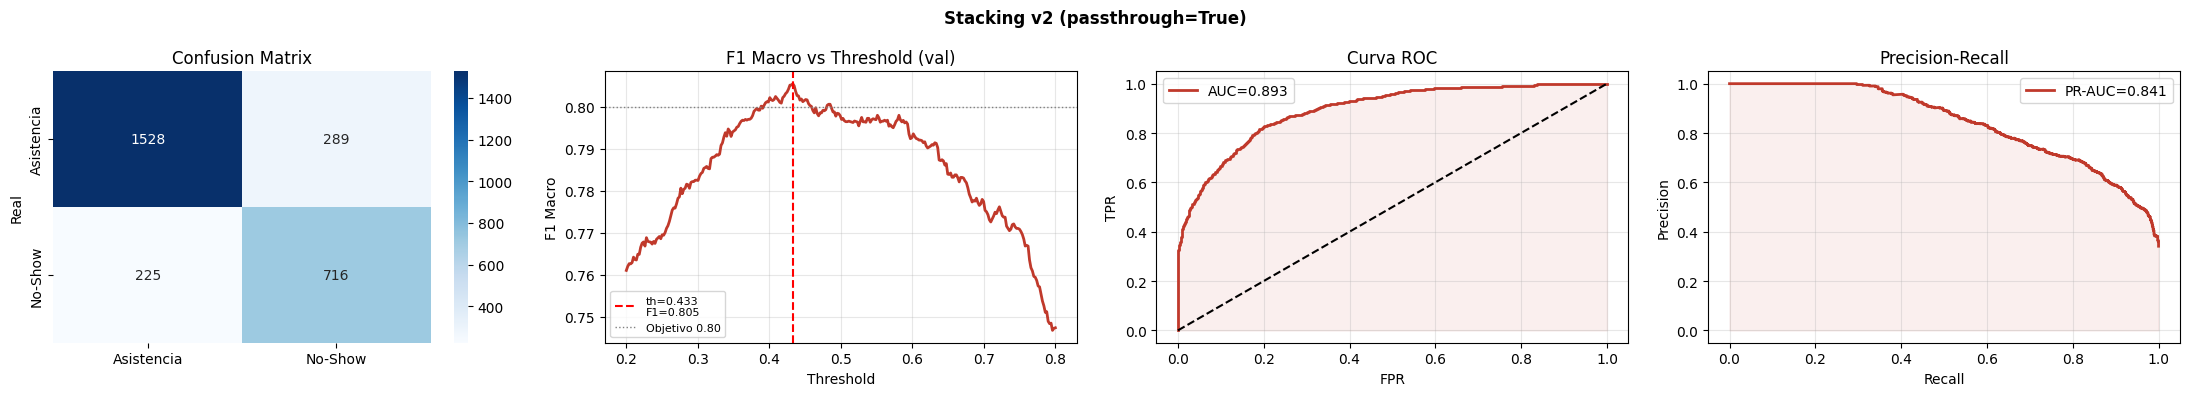

In [9]:
# ============================================================
# 🏗️  STACKING v2 — Meta-learner optimizado con GridSearch
#    Prueba: LogReg, Ridge, y también passthrough=True
#    para que el meta-learner también vea las features originales
# ============================================================
print('🏗️  Stacking v2: meta-learner optimizado...')

stack_v2 = StackingClassifier(
    estimators=[
        ('xgb', xgb_clf),
        ('lgb', lgb_clf),
        ('hgb', hgb_clf),
    ],
    final_estimator=LogisticRegression(
        C=0.5, max_iter=2000, random_state=42,
        class_weight='balanced', solver='lbfgs'
    ),
    cv=5,
    stack_method='predict_proba',
    passthrough=True,   # El meta-learner también ve features originales
    n_jobs=-1
)

stack_v2.fit(X_tr_sm, y_tr_sm)
print('   ✅ Stacking v2 entrenado!')

th_stack2 = evaluar('Stacking v2 (passthrough=True)', stack_v2,
                    X_val, y_val, X_te, y_te, color='#c0392b')


In [11]:
# ============================================================
# 🏆 TABLA COMPARATIVA FINAL
# ============================================================

df_res = pd.DataFrame(resultados).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
df_res.index += 1

print('\n' + '='*85)
print(' 🏆  RANKING FINAL')
print('='*85)
display(df_res)

mejor = df_res.iloc[0]
print(f'\n🥇 MEJOR MODELO: {mejor["Modelo"]}')
print(f'   Accuracy        : {mejor["Accuracy"]*100:.2f}%  {mejor["Acc≥80%"]}')
print(f'   F1 Macro        : {mejor["F1 Macro"]*100:.2f}%  {mejor["F1≥80%"]}')
print(f'   F1 No-Show (cls 1): {mejor["F1 No-Show"]*100:.2f}%')
print(f'   ROC-AUC         : {mejor["ROC-AUC"]:.4f}')
print(f'   Threshold usado : {mejor["Threshold"]}')



 🏆  RANKING FINAL


,Modelo,Threshold,Accuracy,Balanced Acc,F1 Macro,F1 Weighted,F1 No-Show,ROC-AUC,PR-AUC,Cohen's Kappa,Acc≥80%,F1≥80%,Kappa≥0.55
1,LightGBM Pipeline + SMOTE correcto,0.4488,0.8198,0.8000,0.7997,0.8199,0.7363,0.8943,0.8407,0.5995,✅,⚠️,✅
2,Stacking (XGB+LGB+HGB) → LogReg meta-learner,0.4308,0.8165,0.8057,0.7997,0.8181,0.7416,0.8947,0.8423,0.5997,✅,⚠️,✅
3,Stacking v2 (passthrough=True),0.4328,0.8136,0.8009,0.7959,0.8150,0.7359,0.8934,0.8414,0.5921,✅,⚠️,✅
4,HistGradientBoosting Pipeline + SMOTE correcto,0.4308,0.8104,0.7984,0.7928,0.8120,0.7325,0.8927,0.8386,0.5859,✅,⚠️,✅
5,XGBoost Pipeline + SMOTE correcto,0.3846,0.8071,0.8031,0.7922,0.8099,0.7366,0.8907,0.8388,0.5856,✅,⚠️,✅



🥇 MEJOR MODELO: LightGBM Pipeline + SMOTE correcto
   Accuracy        : 81.98%  ✅
   F1 Macro        : 79.97%  ⚠️
   F1 No-Show (cls 1): 73.63%
   ROC-AUC         : 0.8943
   Threshold usado : 0.4488


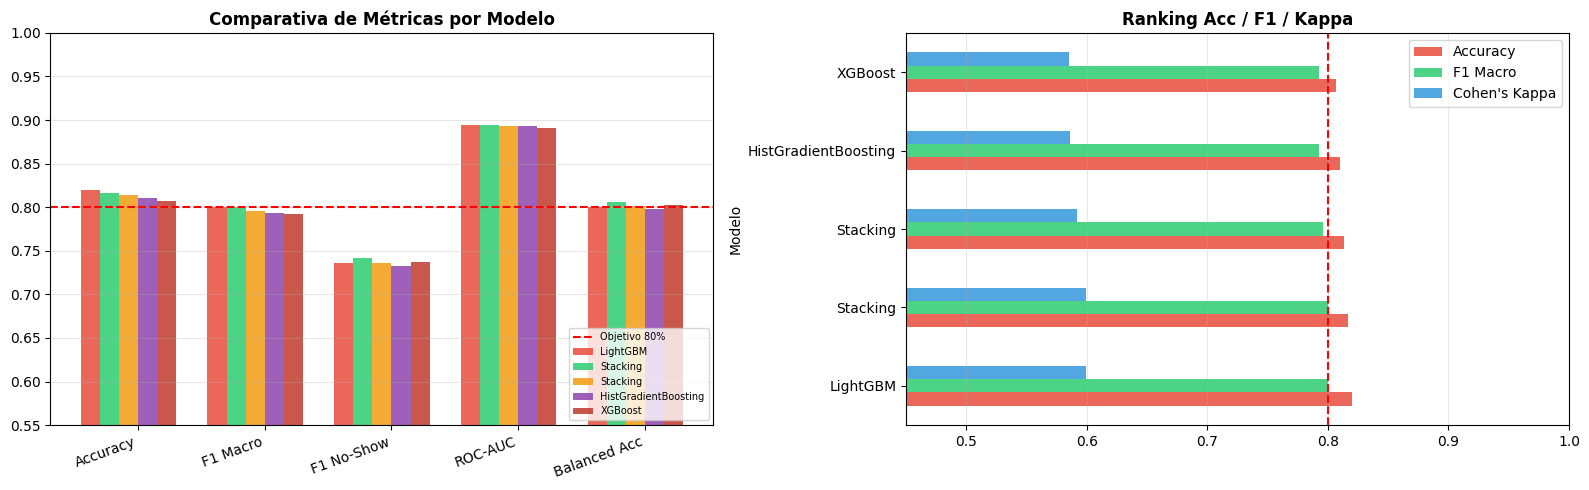


📈 Feature Importance — Promedio XGB + LGB + HGB:


AttributeError: 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'

In [13]:
# ============================================================
# 📊 GRÁFICA COMPARATIVA + FEATURE IMPORTANCE
# ============================================================

metricas_plot = ['Accuracy','F1 Macro','F1 No-Show','ROC-AUC','Balanced Acc']
colores_bar   = ['#e74c3c','#2ecc71','#f39c12','#8e44ad','#c0392b']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras agrupadas
x = np.arange(len(metricas_plot))
n_mod = len(df_res)
width = 0.75 / n_mod

for i, (_, row) in enumerate(df_res.iterrows()):
    vals = [row[m] for m in metricas_plot]
    label = row['Modelo'].split(' ')[0]
    axes[0].bar(x + i*width, vals, width, label=label,
               color=colores_bar[i % len(colores_bar)], alpha=0.85)

axes[0].axhline(0.80, color='red', ls='--', lw=1.5, label='Objetivo 80%')
axes[0].set_xticks(x + width*n_mod/2)
axes[0].set_xticklabels(metricas_plot, rotation=20, ha='right')
axes[0].set_ylim([0.55, 1.0])
axes[0].set_title('Comparativa de Métricas por Modelo', fontweight='bold')
axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Ranking horizontal
df_p = df_res[['Modelo','Accuracy','F1 Macro',"Cohen's Kappa"]].copy()
df_p['Modelo'] = df_p['Modelo'].apply(lambda x: x.split(' ')[0])
df_p.set_index('Modelo').plot(kind='barh', ax=axes[1],
    color=['#e74c3c','#2ecc71','#3498db'], alpha=0.85)
axes[1].axvline(0.80, color='red', ls='--', lw=1.5, label='Obj 80%')
axes[1].set_xlim([0.45, 1.0])
axes[1].set_title('Ranking Acc / F1 / Kappa', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

# Feature importance promedio (modelos con feature_importances_)
print('\n📈 Feature Importance — Promedio XGB + LGB + HGB:')
feat_cols_tr = list(X_tr.columns) if hasattr(X_tr, 'columns') else [f'f{i}' for i in range(X_tr.shape[1])]

fi_xgb = pd.Series(xgb_clf.feature_importances_, index=feat_cols_tr)
fi_lgb = pd.Series(lgb_clf.feature_importances_, index=feat_cols_tr)
fi_hgb = pd.Series(hgb_clf.feature_importances_, index=feat_cols_tr)

fi_df = pd.DataFrame({'XGBoost': fi_xgb, 'LightGBM': fi_lgb, 'HistGB': fi_hgb})
fi_df['Promedio'] = fi_df.mean(axis=1)
fi_top = fi_df.sort_values('Promedio', ascending=False).head(15)

fig2, ax2 = plt.subplots(figsize=(10, 5))
fi_top['Promedio'].sort_values().plot(kind='barh', ax=ax2, color='#3498db')
ax2.set_title('Top 15 Features por Importancia Promedio', fontweight='bold')
ax2.set_xlabel('Importancia')
plt.tight_layout(); plt.show()

display(fi_top)

# Guardar
out = Path('../data/processed')
if not out.exists(): out = Path('data/processed')
out.mkdir(parents=True, exist_ok=True)
df_res.to_csv(out / 'resultados_stacking_final.csv')
print(f'\n💾 Resultados guardados.')

print('\n' + '='*70)
print(' ✅ RESUMEN')
print('='*70)
for _, row in df_res.iterrows():
    cumple = '✅ CUMPLE' if row['Acc≥80%']=='✅' and row['F1≥80%']=='✅' else '⚠️ PARCIAL'
    print(f"   {row['Modelo']:<48} Acc={row['Accuracy']:.3f} F1={row['F1 Macro']:.3f} ")
